In [1]:
## 1. Import Libraries and Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from module_function import AggloMerativeClustering,ClusteringVisualizer

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
df = pd.read_csv('dataset/spotifymusic_CLEANING.csv',nrows=10000)
df.head(3)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4
1,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4
2,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4


In [4]:
## 2. Feature Scaling

In [5]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy="mean")),
    ('scaler',RobustScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__popularity,num__duration_ms,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__time_signature
0,1.193548,0.063771,0.617521,-0.454333,-0.714286,0.147269,-1.0,2.822535,-0.289127,-0.001152,1.436602,0.586957,-0.756770,0.0
1,0.612903,-0.843150,-0.476496,-1.145199,-0.714286,-1.962982,0.0,0.943662,1.076570,-0.001129,-0.168645,-0.386957,-1.002397,0.0
2,0.677419,-0.158215,-0.399573,-0.693208,-0.857143,-0.453878,0.0,0.363380,-0.016845,-0.001157,-0.068707,-0.706522,-1.029649,0.0
3,1.129032,-0.257717,-1.134615,-1.394379,-0.857143,-2.220501,0.0,-0.183099,1.047473,-0.000798,0.024984,-0.656522,1.453183,-1.0
4,1.483871,-0.292179,0.369658,-0.496487,-0.571429,-0.443215,0.0,0.276056,0.379786,-0.001157,-0.281699,-0.604348,-0.002273,0.0


In [6]:
## 3. The Analysis K Selection in AGL

In [7]:
cluster_model = AggloMerativeClustering(range_max=12, df_raw=df)
cluster_model.fit_model(X_cleaned)
cluster_model.compute_scores_dataframe()

[INFO] Model berhasil dilatih untuk semua rentang k.


,n_clusters(k),Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,2,0.334218,3026.143103,1.377705,0.982138
1,3,0.305072,2971.307713,1.398210,0.915976
2,4,0.245213,2536.571153,1.441309,0.706964
3,5,0.254957,2293.829719,1.345040,0.719137
4,6,0.248600,2169.964446,1.362744,0.672253
5,7,0.136360,1977.245702,1.558009,0.358032
6,8,0.140941,1830.230271,1.478340,0.375158
7,9,0.134660,1722.210660,1.605552,0.272076
8,10,0.117194,1624.650108,1.799675,0.118417
9,11,0.106111,1547.059073,1.954641,0.000000


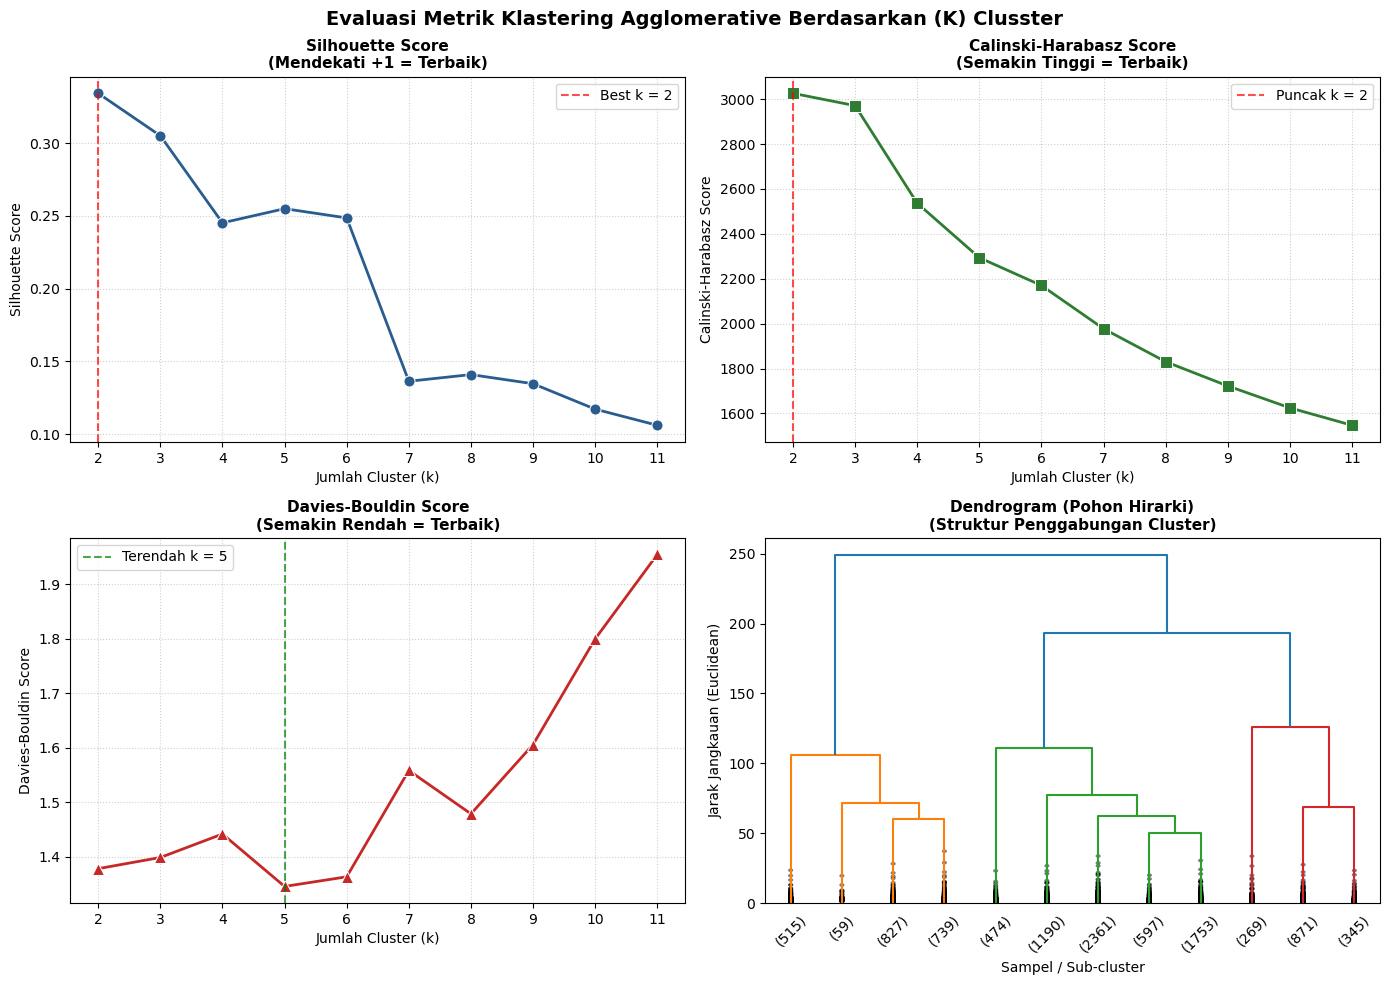

In [8]:
visualizer = ClusteringVisualizer(cluster_model)
visualizer.plot_evaluation_metrics(X_cleaned=X_cleaned)

[INFO] Model optimal dipilih dengan jumlah cluster (k) = 6


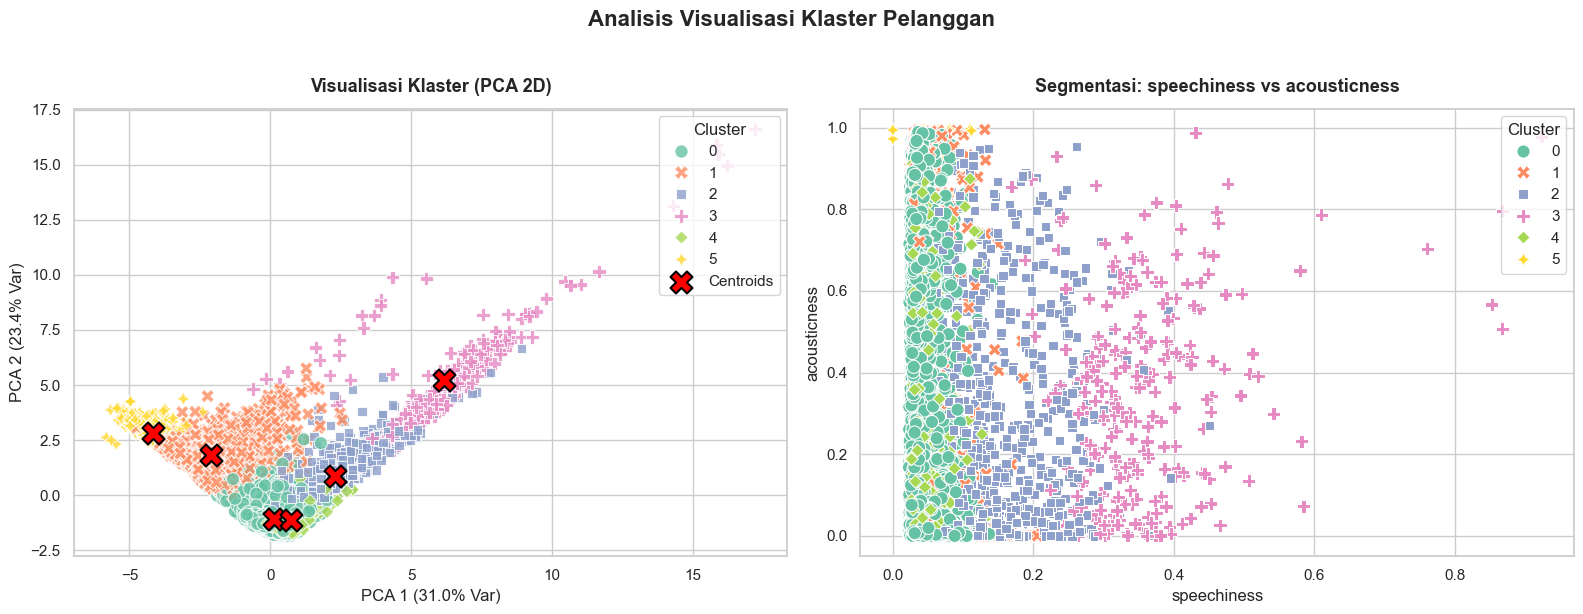

In [9]:
_, df_clustered = cluster_model.fit_best_model(X_cleaned)
visualizer.plot_cluster_results(
    X_cleaned=X_cleaned, 
    feature_x='speechiness',   # Sesuaikan dengan nama kolom dataset Anda
    feature_y='acousticness' # Sesuaikan dengan nama kolom dataset Anda
)

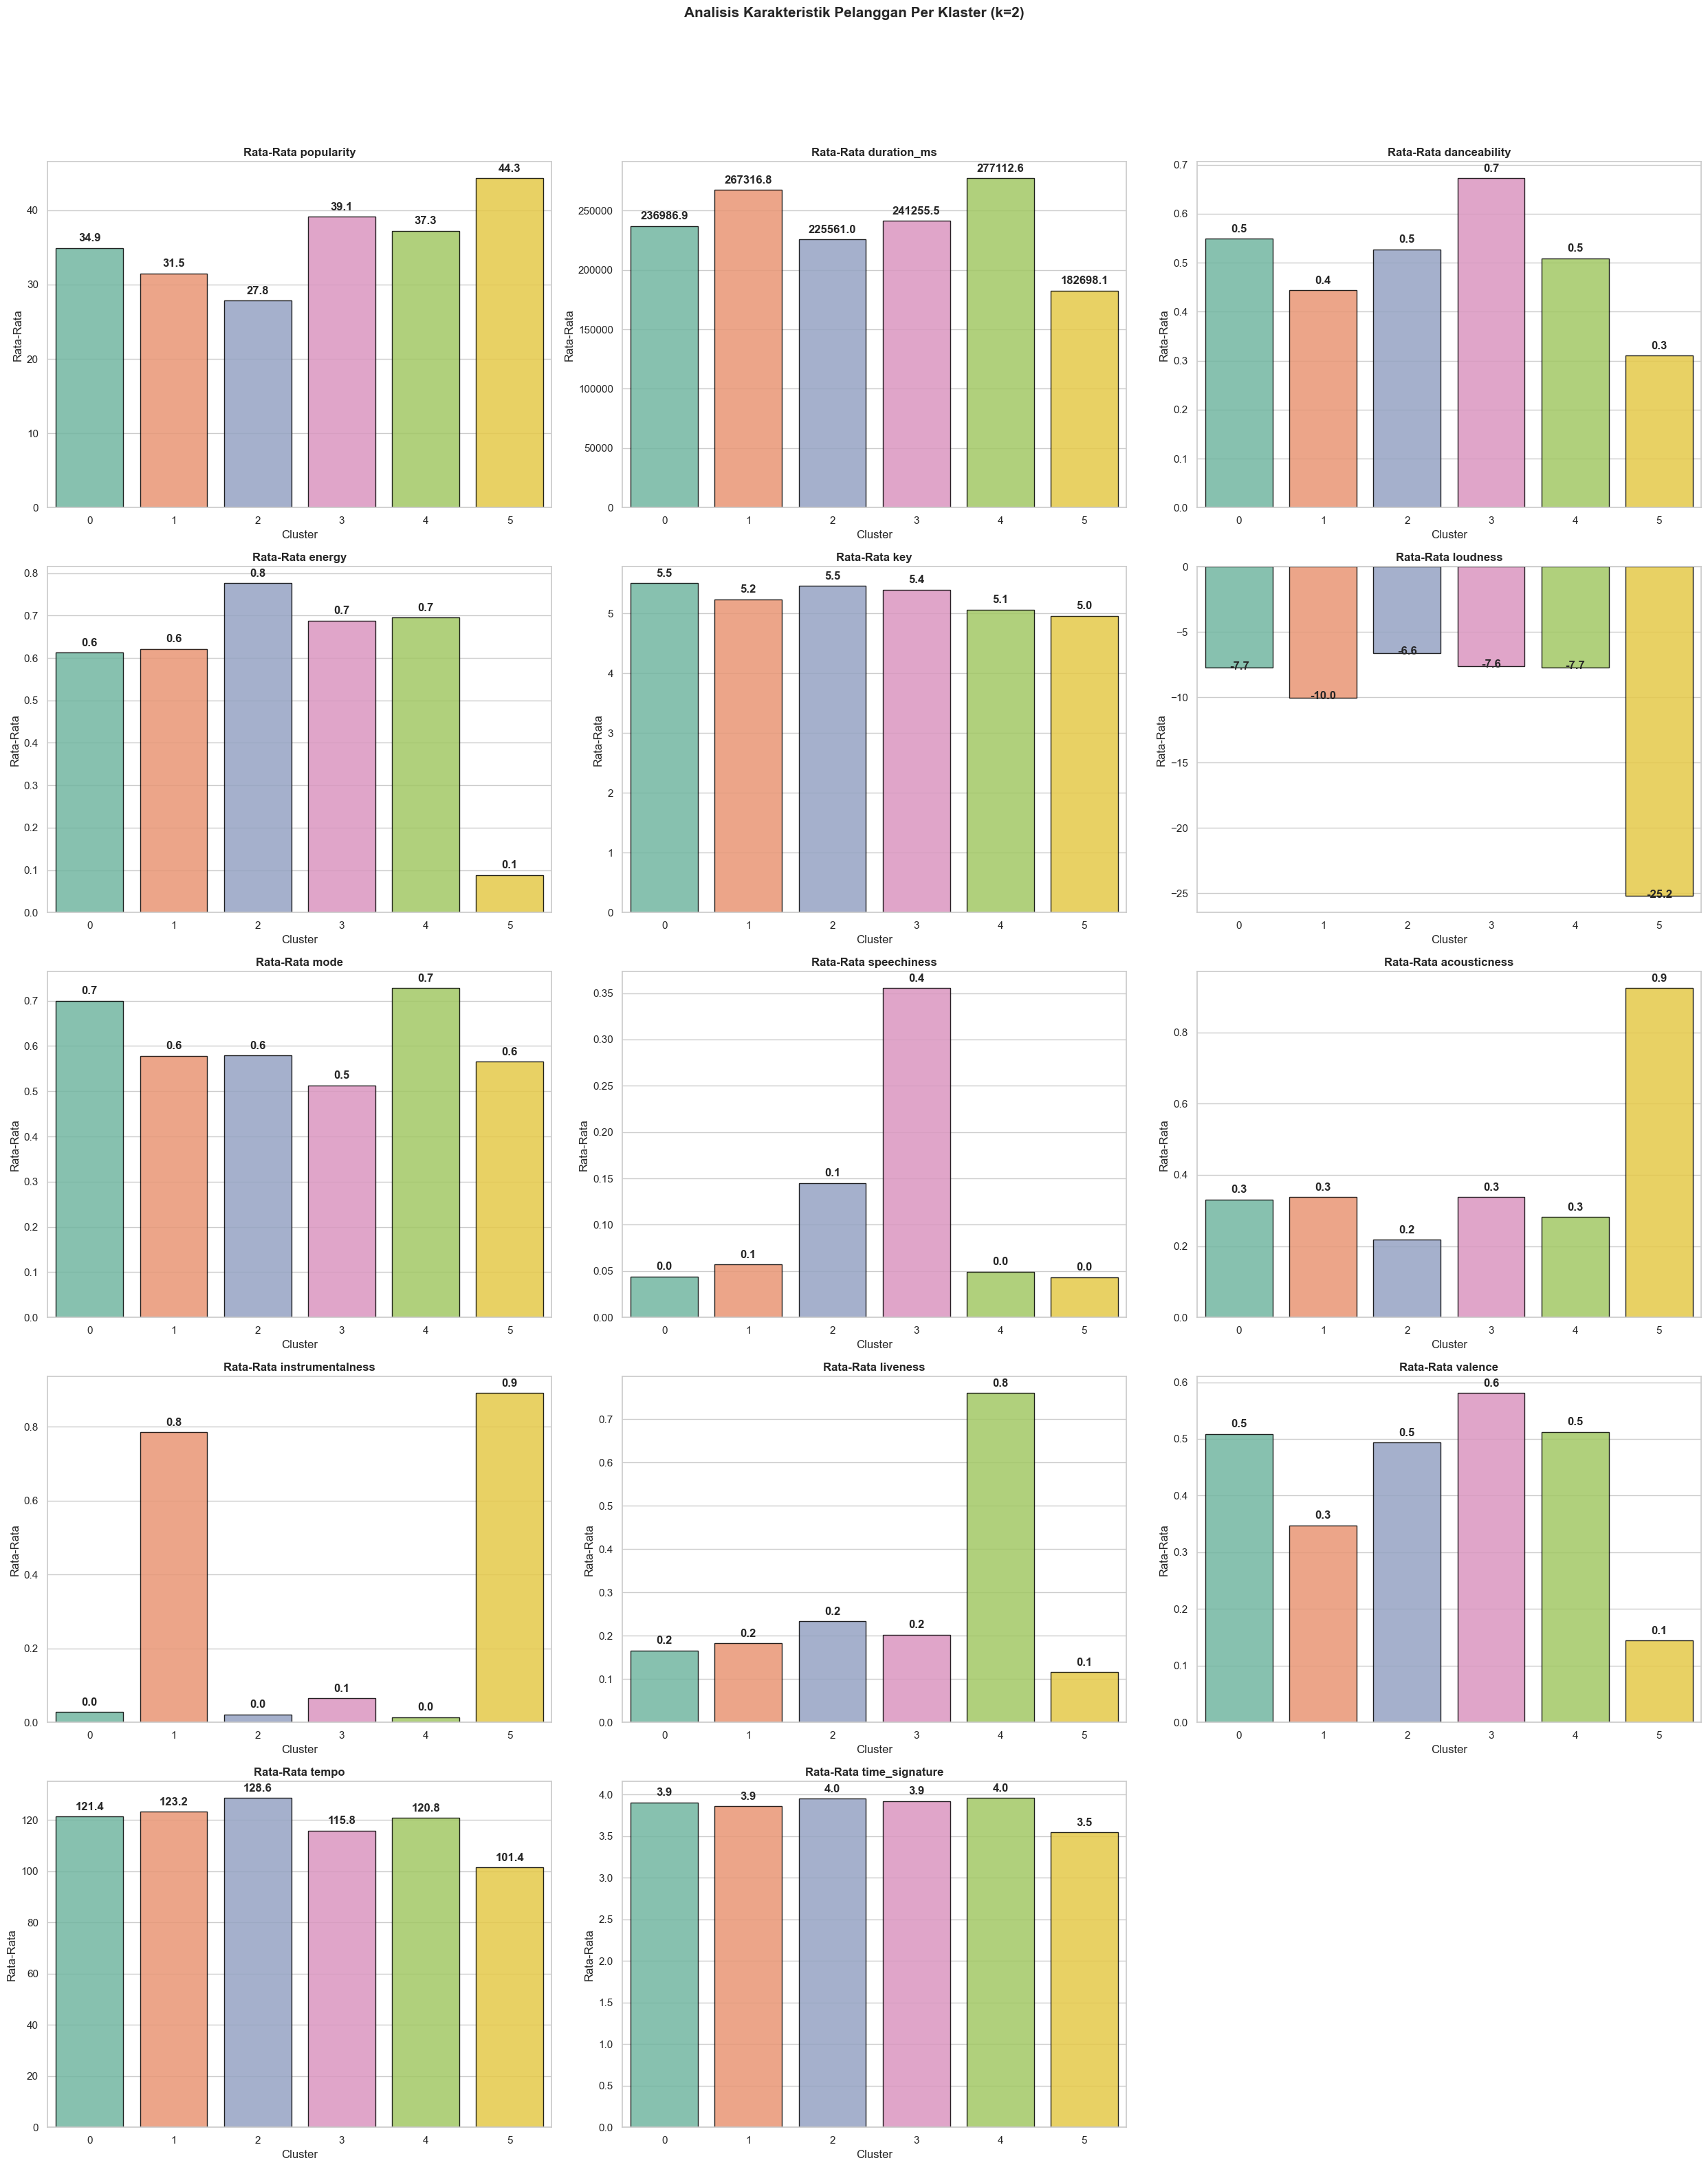

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
visualizer.plot_cluster_characteristic(num_cols)